# You can run sapphire interactively in 3 simple steps:
1. import sapphire
2. define python dictionary of input parameters (see docs) 
3. sapphire.run(parameters) 

In [1]:
import sapphire 

In [3]:
%%prun -s cumulative # I am including this optional magic function so at the end ipynb will print code profiling/timing details

# first we will run on 5 subvolumes of TNG100 
parameters = {'output_path':'/mnt/ceph/users/vpandya/test_sapphire/', # name of output file, NOTE: this will be rewritten as a directory location, and our I/O module will take care writing
              'tree_type':'tng', # type of trees -- this determines what read_trees module gets loaded
              'tree_path':'/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/', # either directory containing tree files or path to single tree file itself in case of TNG experimentation
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':['0_0_0','0_0_1','0_0_2','0_0_3','0_0_4'],
              'num_readers':5,
              'num_writers':5,
              'min_root_mass':1e10, # relevant for TNG, not for FIRE
              'parameter_functions':'fire2', # name of module in parameter_functions with fitting functions for free parameters
              'coolfunc':'wiersma09', # which cooling function to use (wiersma09, sd93, ploeckinger20)
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'Rturb_transition':7.0, # time in Gyr where Rturb logistic function drops to ~half its max value
              'Rturb_slope':2.0, # exponential slope for smoothness/abruptness of Rturb logistic transition
              'f_supp':1.0, # multiply vturb in tff,eff by this to get more turb pressure support for a given vturb
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm              
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'Rturb_type':'RvirLogistic', # either Rvir so Rturb(t)=Rvir(t), or fiducial Rvir-->Rmax logistic from Pandya+22
              'verbose':False, # whether to print values of several properties at each timestep of integration (for debugging)
              'return_all':False} # False for initial solve_ivp call; will be re-run with True to store ALL properties for output 

sapphire.run(parameters)

# this took me 32 min on rusty with a single node with 128 cores (rome nodes)
# ~15 min of that is reading the huge tree files and ~13 min is writing outputs; only 5 min is actually spent on evolving the halos
# this speed will improve when I write a fast custom tree reader, use more efficient data structures, and do parallel writing

Parsing input parameters...
Reading trees...
Reading in trees for subvolume=0_0_1Reading in trees for subvolume=0_0_0Reading in trees for subvolume=0_0_4Reading in trees for subvolume=0_0_2Reading in trees for subvolume=0_0_3




Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_4.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_2.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_1.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Addit

Loading tree roots: 100%|██████████| 5944878712/5944878712 [00:16<00:00, 354363464.65it/s]


Interpolating trees...
Setting up model inputs and parameters...
Evolving model halos...
we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: inv

<!----- WARNING: solve_ivp exited with error for halo_name=1123173629


...

/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s


<!----- WARNING: solve_ivp exited with error for halo_name=1124045859


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # er

Writing results for subvolume=0_0_0
Writing results for subvolume=0_0_1
Writing results for subvolume=0_0_2
Writing results for subvolume=0_0_3
Writing results for subvolume=0_0_4
Finished writing output files to /mnt/ceph/users/vpandya/test_sapphire/
Finished -- thank you for using sapphire!
 

         5563179 function calls (5523114 primitive calls) in 1975.994 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   1153/1    0.004    0.000 1975.996 1975.996 {built-in method builtins.exec}
        1    7.870    7.870 1975.996 1975.996 <string>:1(<module>)
        1    0.001    0.001 1968.123 1968.123 driver.py:22(run)
      287    0.001    0.000 1174.632    4.093 threading.py:582(wait)
      286    0.002    0.000 1174.630    4.107 threading.py:288(wait)
     2000 1174.630    0.587 1174.630    0.587 {method 'acquire' of '_thread.lock' objects}
        2    0.000    0.000 1174.531  587.266 pool.py:359(map)
        2    0.000    0.000 1174.531  587.266 pool.py:764(get)
        2    0.000    0.000 1174.531  587.266 pool.py:761(wait)
        1    0.000    0.000  953.394  953.394 read_tng.py:90(read_trees)
78937/78555    0.048    0.000  786.145    0.010 {built-in method numpy.core._multiarray_umath.implement_array_functi

In [3]:
%%prun -s cumulative

### Now let's update the parameters dict to re-run on raw FIRE-2 trees (so using *net* DM accretion rates via finite differencing Mvir time series)
# we only need to update a few of the dict keys since the other stuff stays the same (and/or will not be used for this tree_type, e.g., subvolumes)
# we will run on all 12 core FIRE-2 halos by default, but if we wanted to do specific ones we could update the halo_names list 

parameters['tree_type'] = 'fire2'
parameters['tree_path'] = '/mnt/ceph/users/vpandya/trees_fire/'

sapphire.run(parameters)

# this took me 3 min of which 2.8 min was spent on reading the huge tree files

Parsing input parameters...
Reading trees...
Reading in tree for m10qReading in tree for m11bReading in tree for m10zReading in tree for m10yReading in tree for m11a




Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/vpandya/trees_fire/tree_m11a.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)
Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/vpandya/trees_fire/tree_m10z.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)
Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/vpandya/trees_fire/tree_m11b.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)
Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/

Loading tree roots: 100%|██████████| 966289540/966289540 [00:03<00:00, 242891236.89it/s]]
/mnt/ceph/users/vpandya/sapphire/sapphire/read_trees/read_fire2.py:45: RuntimeWarning: divide by zero encountered in log10
  logMhires = np.log10(tree['Mvir_hires']) # z=0 Mvir counting only high-res DM particles
/mnt/ceph/users/vpandya/sapphire/sapphire/read_trees/read_fire2.py:45: RuntimeWarning: divide by zero encountered in log10
  logMhires = np.log10(tree['Mvir_hires']) # z=0 Mvir counting only high-res DM particles
Loading tree roots: 100%|██████████| 1295526402/1295526402 [00:05<00:00, 222688870.32it/s]
/mnt/ceph/users/vpandya/sapphire/sapphire/read_trees/read_fire2.py:46: RuntimeWarning: divide by zero encountered in log10
  logMlowres = np.log10(tree['Mvir_lowres']) # z=0 Mvir counting only low-res DM particles
/mnt/ceph/users/vpandya/sapphire/sapphire/read_trees/read_fire2.py:45: RuntimeWarning: divide by zero encountered in log10
  logMhires = np.log10(tree['Mvir_hires']) # z=0 Mvir co

Reading in tree for m11c


Loading tree roots:   0%|          | 25099913/5096556135 [00:00<01:10, 72240947.81it/s]/s]

Reading in tree for m11q


...

Loading tree roots: 100%|██████████| 10751440193/10751440193 [00:34<00:00, 308488498.50it/s]


Interpolating trees...
Setting up model inputs and parameters...
Evolving model halos...
we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: inv

Finished writing output files to /mnt/ceph/users/vpandya/test_sapphire/
Finished -- thank you for using sapphire!
 

         2632667 function calls (2592604 primitive calls) in 187.843 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   1153/1    0.004    0.000  187.845  187.845 {built-in method builtins.exec}
        1    0.015    0.015  187.845  187.845 <string>:1(<module>)
        1    0.000    0.000  187.828  187.828 driver.py:23(run)
      282    0.001    0.000  174.485    0.619 threading.py:582(wait)
      282    0.003    0.000  174.483    0.619 threading.py:288(wait)
     1964  174.431    0.089  174.431    0.089 {method 'acquire' of '_thread.lock' objects}
        2    0.000    0.000  174.340   87.170 pool.py:359(map)
        2    0.000    0.000  174.339   87.170 pool.py:764(get)
        2    0.000    0.000  174.339   87.170 pool.py:761(wait)
        1    0.000    0.000  169.833  169.833 read_fire2.py:106(read_trees)
      177    0.003    0.000   55.196    0.312 __init__.py:1(<module>)
   1342/6    0.005    0.000   10.255    1.70

In [4]:
%%prun -s cumulative

### Finally one more lightning fast run that uses Viraj's small pre-processed MMP history files with particle-based *gross* DM accretion rates
# These are the files that were used for Pandya+22 

parameters['tree_type'] = 'fire2_pandya22' 
# all other parameters stay the same (and/or are unused for this tree_type)

sapphire.run(parameters)

# this took me 8 sec

Parsing input parameters...
Reading trees...
Interpolating trees...
Setting up model inputs and parameters...
Evolving model halos...
we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: inv

Finished writing output files to /mnt/ceph/users/vpandya/test_sapphire/
Finished -- thank you for using sapphire!
 

         388929 function calls (377480 primitive calls) in 8.615 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    8.615    8.615 {built-in method builtins.exec}
        1    0.018    0.018    8.614    8.614 <string>:1(<module>)
        1    0.000    0.000    8.594    8.594 driver.py:23(run)
      268    0.001    0.000    4.692    0.018 threading.py:582(wait)
      268    0.003    0.000    4.690    0.017 threading.py:288(wait)
     1875    4.685    0.002    4.685    0.002 {method 'acquire' of '_thread.lock' objects}
        1    0.000    0.000    4.598    4.598 pool.py:359(map)
        1    0.000    0.000    4.598    4.598 pool.py:764(get)
        1    0.000    0.000    4.598    4.598 pool.py:761(wait)
        1    0.000    0.000    1.621    1.621 context.py:115(Pool)
        1    0.001    0.001    1.621    1.621 pool.py:183(__init__)
        1    0.000    0.000    1.617    1.617 pool.py:302(_

In [1]:
### now let's read in the output files 

%matplotlib inline 
import numpy as np
import matplotlib.pyplot as plt

# first read the runs on the pandya22 FIRE-2 "trees" (gross DM accretion rate)
npz = np.load('/mnt/ceph/users/vpandya/test_sapphire/output_fire2_pandya22.npz',allow_pickle=True)

results_pandya22 = {}
for halo_name in npz.files:
    results_pandya22[halo_name] = npz[halo_name].item()
    
npz.close()

# next read the runs on the raw FIRE-2 trees (net DM accretion rate)
npz = np.load('/mnt/ceph/users/vpandya/test_sapphire/output_fire2.npz',allow_pickle=True)

results_fire2 = {}
for halo_name in npz.files:
    results_fire2[halo_name] = npz[halo_name].item()
    
npz.close()


In [2]:
%%prun -s cumulative

# finally read the runs from the 5 TNG100 subvolumes (all merged into a single dict)
# this takes about 6 min on rusty with the files read in sequentially (multiprocessing is slow for parallel read)

def read_subvolume(subvolume):
    """
    reads in and returns dict of solutions for all halos in single subvolume indexed by root halo_id
    """
    
    print('-----> starting to read subvolume=%s'%subvolume,flush=True)
    npz = np.load('/mnt/ceph/users/vpandya/test_sapphire/output_subvolume_%s.npz'%subvolume,allow_pickle=True)
    
    results_tng = {}

    len_npz = len(npz.files)
          
    for halo_num,halo_name in enumerate(npz.files):
        if halo_num%100 == 0:
            print('finished reading %s/%s solutions for subvolume=%s...'%(halo_num,len_npz,subvolume),flush=True)
          
        results_tng[halo_name] = npz[halo_name].item()

    npz.close()
    
    print('-----> finished reading subvolume=%s'%subvolume,flush=True)
          
    return results_tng 

subvolumes = ['0_0_0','0_0_1','0_0_2','0_0_3','0_0_4']

out = []
    
for subvolume in subvolumes:
    
    out.append(read_subvolume(subvolume))


results_tng_merged = {key:value for d in out for key,value in d.items()}        

# filter out bad/failed TNG solutions 
results_tng_filtered = {key:value for key,value in results_tng_merged.items() if value['sol_success']!=False}

print('Finished!')

-----> starting to read subvolume=0_0_0
finished reading 0/1102 solutions for subvolume=0_0_0...
finished reading 100/1102 solutions for subvolume=0_0_0...
finished reading 200/1102 solutions for subvolume=0_0_0...
finished reading 300/1102 solutions for subvolume=0_0_0...
finished reading 400/1102 solutions for subvolume=0_0_0...
finished reading 500/1102 solutions for subvolume=0_0_0...
finished reading 600/1102 solutions for subvolume=0_0_0...
finished reading 700/1102 solutions for subvolume=0_0_0...
finished reading 800/1102 solutions for subvolume=0_0_0...
finished reading 900/1102 solutions for subvolume=0_0_0...
finished reading 1000/1102 solutions for subvolume=0_0_0...
finished reading 1100/1102 solutions for subvolume=0_0_0...
-----> finished reading subvolume=0_0_0
-----> starting to read subvolume=0_0_1
finished reading 0/1903 solutions for subvolume=0_0_1...
finished reading 100/1903 solutions for subvolume=0_0_1...
finished reading 200/1903 solutions for subvolume=0_0_1.

         323604933 function calls (323566119 primitive calls) in 394.064 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  394.064  394.064 {built-in method builtins.exec}
        1    0.000    0.000  394.063  394.063 <string>:1(<module>)
        5    0.560    0.112  394.050   78.810 <string>:4(read_subvolume)
     6469    0.411    0.000  393.222    0.061 npyio.py:232(__getitem__)
     6469    0.074    0.000  391.754    0.061 format.py:730(read_array)
     6469  178.499    0.028  389.283    0.060 {built-in method _pickle.load}
 39775997   45.227    0.000  166.220    0.000 zipfile.py:880(peek)
 69254068   96.663    0.000  161.746    0.000 zipfile.py:898(read)
  5882565    7.360    0.000   57.268    0.000 zipfile.py:980(_read1)
  5882565    7.010    0.000   34.431    0.000 zipfile.py:1016(_read2)
  5921379    9.619    0.000   24.089    0.000 zipfile.py:736(read)
  5882565    2.366    0.000   14.97

Text(0, 0.5, '$M_{\\rm star}/M_{\\rm vir}$')

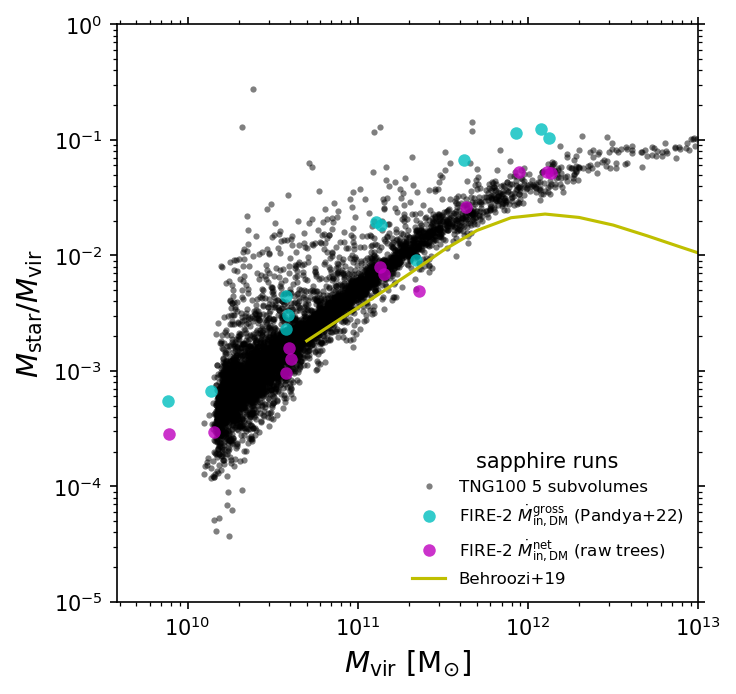

In [3]:
from astropy.table import Table
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

### overplot z=0 SMHM relation with individual FIRE points from both sets of runs (gross and net DM accretion rate)

# first collect z=0 (Mstar,Mvir) tuple for every object 

smhm_pandya22 = np.array([(d['M_star'][-1],d['Mvir'][-1]) for d in results_pandya22.values()])

smhm_fire2 = np.array([(d['M_star'][-1],d['Mvir'][-1]) for d in results_fire2.values()])

smhm_tng = np.array([(d['M_star'][-1],d['Mvir'][-1]) for d in results_tng_filtered.values()])


# now plot

fig, ax = plt.subplots(1,figsize=(5,5),dpi=150)

ax.plot(smhm_tng[:,1],smhm_tng[:,0] / smhm_tng[:,1],'k.',alpha=0.5,mec='none',label='TNG100 5 subvolumes')

ax.plot(smhm_pandya22[:,1],smhm_pandya22[:,0] / smhm_pandya22[:,1],'co',alpha=0.8,mec='none',label=r'FIRE-2 $\dot{M}_{\rm in,DM}^{\rm gross}$ (Pandya+22)')

ax.plot(smhm_fire2[:,1],smhm_fire2[:,0] / smhm_fire2[:,1],'mo',alpha=0.8,mec='none',label=r'FIRE-2 $\dot{M}_{\rm in,DM}^{\rm net}$ (raw trees)')

# read in Behroozi+19 UniverseMachine DR1 Median SMHM relation  (discard below logmvir<10.5 due to Bolshoi-Planck incompleteness)
tum = Table.read('/mnt/ceph/users/vpandya/umachine-dr1/data/smhm/median_raw/smhm_a1.002312.dat',format='ascii')
tum = tum[tum['HM(0)']>10.5]
ax.plot(10**tum['HM(0)'],10**tum['Med_All(1)'],c='y',ls='-',label='Behroozi+19')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(None,1e13)
ax.set_ylim(1e-5,1e0)

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0,title='sapphire runs')

ax.set_xlabel(r'$M_{\rm vir}$ [M$_{\odot}$]',fontsize=14)
ax.set_ylabel(r'$M_{\rm star}/M_{\rm vir}$',fontsize=14)


Text(0, 0.5, '$Z_{\\rm ISM}/Z_{\\odot}$')

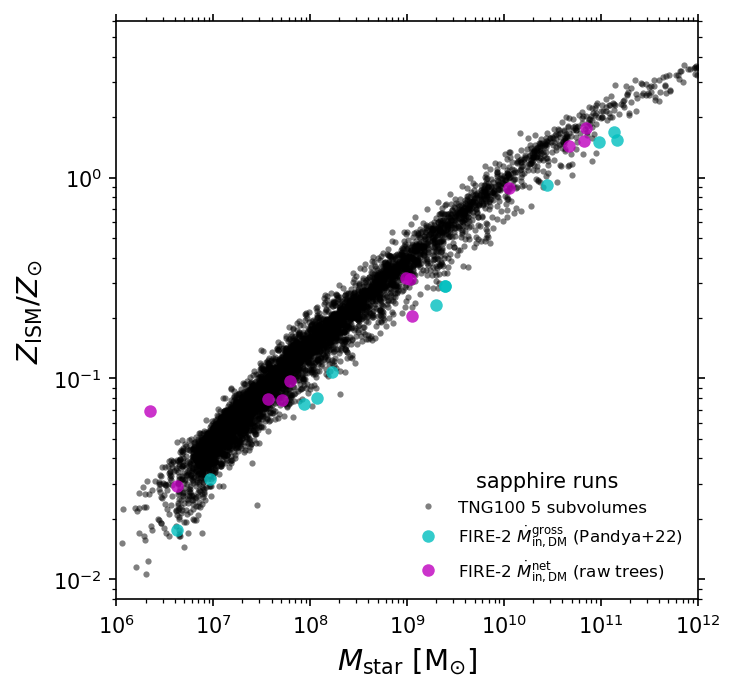

In [4]:
# now plot the z=0 gas MZR 

# first collect z=0 (Mstar,Zism) tuple for every object 

mzr_pandya22 = np.array([(d['M_star'][-1],d['MZ_ism'][-1] / d['M_ism'][-1] / 0.02) for d in results_pandya22.values()])

mzr_fire2 = np.array([(d['M_star'][-1],d['MZ_ism'][-1] / d['M_ism'][-1] / 0.02) for d in results_fire2.values()])


mzr_tng = np.array([(d['M_star'][-1],d['MZ_ism'][-1] / d['M_ism'][-1] / 0.02) for d in results_tng_filtered.values()])


# now plot

fig, ax = plt.subplots(1,figsize=(5,5),dpi=150)

ax.plot(mzr_tng[:,0],mzr_tng[:,1],'k.',alpha=0.5,mec='none',label='TNG100 5 subvolumes')

ax.plot(mzr_pandya22[:,0],mzr_pandya22[:,1],'co',alpha=0.8,mec='none',label=r'FIRE-2 $\dot{M}_{\rm in,DM}^{\rm gross}$ (Pandya+22)')

ax.plot(mzr_fire2[:,0],mzr_fire2[:,1],'mo',alpha=0.8,mec='none',label=r'FIRE-2 $\dot{M}_{\rm in,DM}^{\rm net}$ (raw trees)')




ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e6,1e12)
ax.set_ylim(8e-3,6e0)

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0,title='sapphire runs')

ax.set_xlabel(r'$M_{\rm star}$ [M$_{\odot}$]',fontsize=14)
ax.set_ylabel(r'$Z_{\rm ISM}/Z_{\odot}$',fontsize=14)


In [ ]:
# let's also overplot time series of some key properties 
# for each fire halo, we'll get 5 random TNG halos with similar Mvir(z=0) for comparison



# Jan 2023: testing manually on rusty for new TNG tree reader function

In [ ]:
from sapphire.read_trees import read_tng, read_fire2_pandya22, interpolate_trees
from sapphire.parameter_functions import fire2 as param_functions 
from sapphire.parameter_functions import uvb_filtering
from sapphire.coolfunc import read_coolfunc 
from sapphire.physical_models import fiducial_model 

import multiprocessing
import numpy as np
from functools import partial
import os

%matplotlib inline
import matplotlib.pyplot as plt 

In [ ]:
parameters = {'output_path':'/mnt/ceph/users/vpandya/test_sapphire/', # name of output file, NOTE: this will be rewritten as a directory location, and our I/O module will take care writing
              'tree_type':'tng', # type of trees -- this determines what read_trees module gets loaded
              'tree_path':'/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/', # either directory containing tree files or path to single tree file itself in case of TNG experimentation
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':['0_0_0','0_0_1','0_0_2','0_0_3','0_0_4'],
              'num_readers':5,
              'num_writers':5,
              'min_root_mass':1e10, # relevant for TNG, not for FIRE
              'parameter_functions':'fire2', # name of module in parameter_functions with fitting functions for free parameters
              'coolfunc':'wiersma09', # which cooling function to use (wiersma09, sd93, ploeckinger20)
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'Rturb_transition':7.0, # time in Gyr where Rturb logistic function drops to ~half its max value
              'Rturb_slope':2.0, # exponential slope for smoothness/abruptness of Rturb logistic transition
              'f_supp':1.0, # multiply vturb in tff,eff by this to get more turb pressure support for a given vturb
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm              
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'Rturb_type':'RvirLogistic', # either Rvir so Rturb(t)=Rvir(t), or fiducial Rvir-->Rmax logistic from Pandya+22
              'verbose':False, # whether to print values of several properties at each timestep of integration (for debugging)
              'return_all':False} # False for initial solve_ivp call; will be re-run with True to store ALL properties for output 


In [ ]:
%%prun -s cumulative
tree_tables = read_tng.read_trees(parameters)

Reading in trees for subvolume=0_0_1Reading in trees for subvolume=0_0_0Reading in trees for subvolume=0_0_3Reading in trees for subvolume=0_0_4Reading in trees for subvolume=0_0_2




Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_0.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_1.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_3.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)Additional features and improved performance (usua

Loading tree roots: 100%|██████████| 5944878712/5944878712 [00:16<00:00, 355832869.19it/s]


         2236 function calls (2232 primitive calls) in 959.904 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      5/1    0.000    0.000  959.904  959.904 {built-in method builtins.exec}
        1    0.000    0.000  959.903  959.903 <string>:1(<module>)
        1    0.000    0.000  959.903  959.903 read_tng.py:90(read_trees)
       14    0.000    0.000  959.837   68.560 threading.py:582(wait)
       89  959.837   10.785  959.837   10.785 {method 'acquire' of '_thread.lock' objects}
       14    0.000    0.000  959.837   68.560 threading.py:288(wait)
        1    0.000    0.000  959.833  959.833 pool.py:359(map)
        1    0.000    0.000  959.833  959.833 pool.py:764(get)
        1    0.000    0.000  959.833  959.833 pool.py:761(wait)
        1    0.000    0.000    0.046    0.046 context.py:115(Pool)
        1    0.000    0.000    0.044    0.044 pool.py:183(__init__)
        1    0.000    0.000    0.040    0.040 pool.p

In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import gaussian_filter1d
from astropy.table import Table


def interp_run(tree_tables):
    """
    Performs a smooth interpolation of redshift, DM accretion rate, Mvir, Rvir, Vvir, NFW concentration
    for each halo's most massive progenitor history provided in tables_halos -- these properties should
    already be made available by the relevant read_*.py module. The interpolation is done vs. cosmic age
    (time since Big Bang) in Gyr.
    
    NOTE: We generally interpolate in log-space since that is better behaved for many of our properties that
    change by orders of magnitude as a function of time. This should be fine for Mvir, Rvir, cNFW, etc. but 
    it should be checked for the DM accretion rate -- especially if it's a net rather than gross rate since
    the former can be <= 0 thus making log10 undefined. Net accretion rates must necessarily be used for 
    large-volume simulations by finite-differencing the Mvir time series, so those are particularly susceptible.
    
    Returns a list of N lists of size M where N is the number of halos and M is the number of requested
    property interpolator objects -- the lists are 1:1 mapped with the input tree_tables
    
    tree_tables is a dict of Astropy Tables giving the tree for each halo (the keys of this dict are the halo names/IDs)
    """
    
    # initialize an empty dict that will store lists of interpolators for each halo with the key being the halo_name
    tree_interpolators = {}
    
    # loop over each tree and create then store the needed interpolator objects
    for tname in tree_tables.keys():
        t = tree_tables[tname]

        # NOTE: extrapolation is not allowed and will raise an error (we do not want to introduce garbage data for early unresolved history)

        # faster to interpolate snapshot redshift than do cosmology root-finding calculation
        interp_redshift = UnivariateSpline(t['cosmic_age'],t['redshift'],k=5,s=0) 

        # log10 of DM accretion rate in Msun/yr
        interp_logMAR = UnivariateSpline(t['cosmic_age'],np.log10(gaussian_filter1d(t['dm_accretion_rate'],10,mode='nearest')),k=5,s=2) 

        # log10 of Mvir in Msun (no little-h)
        interp_logMvir = UnivariateSpline(t['cosmic_age'],gaussian_filter1d(t['log_mvir'],10,mode='nearest'),k=5,s=2) 

        # log10 of Rvir in proper kpc (no little-h)
        interp_logRvir = UnivariateSpline(t['cosmic_age'],gaussian_filter1d(t['log_rvir'],10,mode='nearest'),k=5,s=2)

        # log10 of Vvir := sqrt(GMvir/Rvir) in proper km/s 
        interp_logVvir = UnivariateSpline(t['cosmic_age'],gaussian_filter1d(t['log_vvir'],10,mode='nearest'),k=5,s=2) 

        # log10 of NFW halo concentration := Rvir / Rs_Klypin 
        interp_logcNFW = UnivariateSpline(t['cosmic_age'],gaussian_filter1d(t['log_cNFW'],10,mode='nearest'),k=5,s=2) 
        
        # finally add a list for this halo to tree_interpolators dict with this tree name being the key -- the parent module should respect the list order! 
        tree_interpolators[tname] = [interp_redshift,interp_logMAR,interp_logMvir,interp_logRvir,interp_logVvir,interp_logcNFW]
        
    return tree_interpolators

In [61]:
tree_interpolators = interp_run(tree_tables)

In [76]:
# retrieve the list of parameter fitting functions in the order expected for unpacking by the integrator
list_param_functions = param_functions.get()

# retrieve the list of UVB filtering mass and collapse fraction functions
list_uvb_filtering = uvb_filtering.get()

# read cooling function and create N-dimensional interpolator object
coolfunc = read_coolfunc.return_coolfunc('wiersma09')

In [77]:
pool_integrator = partial(fiducial_model.integrator,parameters=parameters,parameter_functions=list_param_functions,uvb_model=list_uvb_filtering,coolfunc=coolfunc)

In [78]:
halo_data_tuples = [(k,v) for k,v in tree_interpolators.items()]

In [79]:
%%prun -s cumulative

# set up for python single-node parallel processing
PoolProcesses = multiprocessing.cpu_count()
print('we will process %s trees in parallel'%PoolProcesses,flush=True)

# start pool process 
pool = multiprocessing.Pool(processes=PoolProcesses) 

# call the pool_integrator function in parallel with each pair in halo_data_tuples as inputs
out = pool.map(pool_integrator,halo_data_tuples)

# close pool processes to free memory
pool.close()
pool.join()

print('Finished!')

we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: inv

<!----- WARNING: solve_ivp exited with error for halo_name=1123173629


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt

<!----- WARNING: solve_ivp exited with error for halo_name=1123182246


...

/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3


<!----- WARNING: solve_ivp exited with error for halo_name=1124045859


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/

Finished!
 

         34509 function calls in 258.494 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  258.494  258.494 {built-in method builtins.exec}
        1    0.003    0.003  258.494  258.494 <string>:1(<module>)
      261    0.019    0.000  240.754    0.922 threading.py:582(wait)
      261    0.003    0.000  240.734    0.922 threading.py:288(wait)
     1820  240.734    0.132  240.734    0.132 {method 'acquire' of '_thread.lock' objects}
        1    0.000    0.000  240.649  240.649 pool.py:359(map)
        1    0.000    0.000  240.649  240.649 pool.py:764(get)
        1    0.000    0.000  240.649  240.649 pool.py:761(wait)
        1    0.000    0.000   16.420   16.420 context.py:115(Pool)
        1    0.000    0.000   16.420   16.420 pool.py:183(__init__)
        1    0.000    0.000   16.409   16.409 pool.py:302(_repopulate_pool)
        1    0.005    0.005   16.409   16.409 pool.py:311(_repopulate_p

In [80]:
# collapse the list of dicts into a single dict with halo_name:results_dict pairs 
dict_results = {key:value for d in out for key,value in d.items()}

In [81]:
len(dict_results) 

6469

In [82]:
dfalse = {key:value for key,value in dict_results.items() if value['sol_success']==False}

In [84]:
dfalse

{'1123182246': {'sol_success': False, 'sol_object': None},
 '1123173629': {'sol_success': False, 'sol_object': None},
 '1123379757': {'sol_success': False, 'sol_object': None},
 '1123422273': {'sol_success': False, 'sol_object': None},
 '1123426377': {'sol_success': False, 'sol_object': None},
 '1123628738': {'sol_success': False, 'sol_object': None},
 '1123628489': {'sol_success': False, 'sol_object': None},
 '1123811070': {'sol_success': False, 'sol_object': None},
 '1123822975': {'sol_success': False, 'sol_object': None},
 '1123818390': {'sol_success': False, 'sol_object': None},
 '1124032059': {'sol_success': False, 'sol_object': None},
 '1124037509': {'sol_success': False, 'sol_object': None},
 '1124045859': {'sol_success': False, 'sol_object': None},
 '1124262196': {'sol_success': False, 'sol_object': None}}

In [83]:
len(dfalse)

14

In [100]:
tree_tables[int(list(dfalse.keys())[13])]

haloID,root_haloID,subvolume,redshift,cosmic_age,log_mvir,log_rvir,log_cNFW,log_vvir,dm_accretion_rate
int64,int64,str5,float32,float64,float64,float64,float32,float64,float64
3230964,1124262196,0_0_4,11.980269,0.3683760444781437,8.75991352807092,0.26140022450271005,0.7397479,1.5660371961822517,4.962705738857259
6218840,1124262196,0_0_4,10.976048,0.41580186222766735,8.908852539932678,0.34599314862963515,0.7232644,1.5982102400496687,2.9856282889710273
10044082,1124262196,0_0_4,9.996262,0.4727354549501824,8.991522135421226,0.4105772033916838,0.6661153,1.6072530104129183,2.1703739680971093
14617814,1124262196,0_0_4,9.388532,0.5149074385990586,9.030274697880236,0.4481677576403562,0.4763885,1.6078340145180874,8.662006577243044
20199433,1124262196,0_0_4,9.002001,0.545098089306433,9.125061045022047,0.49622245467933623,0.4488361,1.6311998395695024,14.52385100769739
26649663,1124262196,0_0_4,8.449117,0.5937133695191688,9.309585452682233,0.582379831451807,0.49222615,1.6803833550133604,8.667517197325955
34023260,1124262196,0_0_4,8.012257,0.6374619738430882,9.383632592516769,0.6275875013609782,0.6618709,1.694803089976042,14.170205109324353
42223459,1124262196,0_0_4,7.594757,0.684522301167562,9.489372875708794,0.6833956175315907,0.5532365,1.7197691734867488,7.2360788451349025
51096562,1124262196,0_0_4,7.236554,0.7296972374342284,9.53310137600133,0.716435767644103,0.46383548,1.7251133485767605,0.8223581159419537


In [ ]:
import numpy as np
from astropy import constants as const
from astropy import units as u
from astropy.cosmology import Planck15 
from scipy.integrate import simps, solve_ivp

# define constants and unit conversions globally for this module 
const_mp = const.m_p.to('Msun').value 
cm_to_kpc = u.cm.to('kpc') # multiply something in cm by this to get to kpc 
kpc_to_cm = u.kpc.to('cm') # multiply something in kpc, it becomes units of cm
const_kB = const.k_B.to('erg/K').value # so that k*T = erg by default
yr_to_s = u.yr.to('s') # if you multiply something in yr by this, you get it in units of sec
s_to_yr = u.s.to('yr')
Msun_to_g = u.Msun.to('g') 
f_b = Planck15.Ob0 / Planck15.Om0 # ~15 %
G = const.G.to('cm**3 / (g * s**2)').value

# define analytic functions to return n0 (density within Rvir) and T0 (temperature at Rvir) given state variables and assumed profile slopes
# NOTE: this is temporarily here -- eventually will be moved to the relevant subgrid_recipes CGM module 
def analytic_n0(Mcgm,Rvir,alpha_n):
    Rvir = Rvir * kpc_to_cm
    return (3+alpha_n)*Mcgm*Rvir**(alpha_n) / (4*np.pi * 0.59*const_mp * (Rvir**(3+alpha_n) - (0.1*Rvir)**(3+alpha_n))) # cm**-3

def analytic_T0(Ecgm,Rvir,n0,alpha_n,alpha_T):
    Rvir = Rvir * kpc_to_cm
    T0_est = (alpha_n+alpha_T+3)*Rvir**(alpha_n+alpha_T) * Ecgm / (6*np.pi*n0*const_kB*(Rvir**(alpha_n+alpha_T+3)-(0.1*Rvir)**(alpha_n+alpha_T+3))) # K
    return np.nan_to_num(T0_est,nan=1,posinf=1,neginf=1) # at early times when Mcgm=0, n0=0 so T0=nan; return 1K


def evolve_galaxy(t,y,parameters,tree_interpolators,parameter_functions,uvb_model,coolfunc):
    """
    Returns the LHS of the ODE system at time t with the current value of the
    state variables in the list y (output ydot's are 1:1 mapped with list y).
    
    The parameters dict gives the user-provided parameters.
    
    tree_interpolators is the list of smooth interpolation functions that give
    required halo merger tree properties as a function of time. 
    
    parameter_functions are the functions that give astrophysical parameters
    as a function of Vvir, redshift, etc. 
    
    uvb_model provides two functions: filtering mass and collapse fraction.
    
    coolfunc is the interpolator function for the assumed cooling function
    """
    
    # unpack the state variables
    M_star = y[0]
    M_ism = y[1]
    M_cgm = y[2]
    Eth_cgm = y[3]
    Ekin_cgm = y[4]
    MZ_star = y[5]
    MZ_ism = y[6]
    MZ_cgm = y[7]
    
    # unpack our SAM's free parameters
    alpha_n = parameters['alpha_n']
    alpha_T = parameters['alpha_T']
    tau_escape = parameters['tau_escape']
    f_recycle = parameters['f_recycle']
    Rturb_transition = parameters['Rturb_transition']
    Rturb_slope = parameters['Rturb_slope']
    f_supp = parameters['f_supp']    
    e_wind_halo = parameters['e_wind_halo']
    yZ = parameters['yZ']
    Rturb_type = parameters['Rturb_type']
    verbose = parameters['verbose']    
    return_all = parameters['return_all']
    
    # unpack tree_interpolators (note the order of the returned list elements in read_trees/interpolate_trees.py module)
    interp_redshift, interp_logMAR, interp_logMvir, interp_logRvir, interp_logVvir, interp_logcNFW = tree_interpolators
    
    # unpack parameter_functions
    get_tdep, get_etaM_ism, get_vB_ism, get_Zin_halo, get_fprev, get_fthermal_accretion, get_fthermal_wind = parameter_functions 
    
    # unpack uvb_model 
    m_filt, collapse_fraction = uvb_model 
    
    # get Mdot_in_dm, Vvir and other quantities at this time using my interpolator functions 
    # I do .item() since scipy returns 0d array instead of scalar because of some convention ... 
    t_Gyr = t * s_to_yr * 1e-9 # back to Gyr since our interpolations were done vs. Gyr
    print('working on t_Gyr=%s'%t_Gyr)
    redshift = interp_redshift(t_Gyr).item() # dimensionless    
    Mdot_in_dm = 10**interp_logMAR(t_Gyr).item() # Msun/yr 
    Mvir = 10**interp_logMvir(t_Gyr).item() # Msun
    Rvir = 10**interp_logRvir(t_Gyr).item() # proper kpc
    Vvir = 10**interp_logVvir(t_Gyr).item() # proper km/s
    NFW_c = 10**interp_logcNFW(t_Gyr).item() # dimensionless NFW halo concentration = Rvir/Rs_klypin
    
    # compute effective free-fall radius as the radius of Vmax ~ 2.16*Rscale ~ 2.16 * Rvir/cNFW 
    rff = 2.16 * (Rvir / NFW_c) / Rvir # in units of Rvir
    
    # compute Rturb
    if Rturb_type == 'Rvir': # Rturb(t) = Rvir(t)
        Rturb = Rvir
    if Rturb_type == 'RvirLogistic': # Rturb(t) = logistic function that goes from Rvir(t) at early times to Rmax(t) at late times
        Rturb = rff*Rvir + (Rvir-rff*Rvir) / (1.0 + np.exp(Rturb_slope*(t_Gyr-Rturb_transition))) # pkpc    
    
    # compute any other global halo quantities 
    Tvir = 35.9 * Vvir**2 # K 
    evir_halo = 3/2. * const_kB * Tvir / (0.59*const_mp) # erg/Msun  
    tdyn_halo = Rvir / (Vvir * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # analytic formula for NFW Vcirc(rff:=r/Rvir) rom Mo, van den Bosch & White eqn 11.26
    NFW_vcirc_num = np.log(1+NFW_c*rff) - NFW_c*rff/(1+NFW_c*rff)
    NFW_vcirc_den = rff*(np.log(1+NFW_c)-NFW_c/(1+NFW_c))
    NFW_vcirc = Vvir*np.sqrt(NFW_vcirc_num/NFW_vcirc_den) # km/s
    tdyn_ism = rff*Rvir / (NFW_vcirc * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # get SF and ISM wind scalings from FIRE 
    tdep_ism = get_tdep(Vvir,redshift) # Gyr 
    etaM_ism = get_etaM_ism(Vvir,redshift) # dimensionless
    vB_ism = get_vB_ism(Vvir,redshift) # km/s

    # new FIRE Zdot/Mdot scalings for chemical evolution modeling
    Zin_halo = get_Zin_halo(Vvir,redshift) # dimensionless Zdot/Mdot (*not* normalized to Zsun)
    # Zcool = get_Zin_ism(Vvir,redshift) # dimensionless Zdot/Mdot (*not* normalized to Zsun)
    # Zwind = get_Zout_ism(Vvir,redshift) # dimensionless Zdot/Mdot (*not* normalized to Zsun)
    # Zout_halo = get_Zout_halo(Vvir,redshift) # dimensionless Zdot/Mdot (*not* normalized to Zsun)
    
    # compute log10 of CGM metallicity normalized to Zsun for cooling function
    log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
        
    ### compute Mdot_in_halo and Edot_in_halo terms 
    # first f_UV for UVB photoionization suppression of halo inflows
    Mfilt = m_filt(z=redshift)
    f_UV = collapse_fraction(Mvir,Mfilt)  
    
    # f_prev due to SN wind shock heating 
    # in the future will add zeta=Edot_out_halo_previous / (evir_halo*Mdot_in_halo) here 
    
    # assume this gas accretion brings in specific energy = evir_halo
    # f_prev will be computed and multiply both of these inflow rates AFTER we compute the halo energy outflow rate below
    Mdot_in_halo = f_UV * f_b * Mdot_in_dm # Msun/yr
    Edot_in_halo = Mdot_in_halo * evir_halo / yr_to_s # erg/s 
    
    ### compute turbulent energy dissipation rate (rate at which Ekin_cgm decays into Eth_cgm)
    vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
    tturb_cgm = (Rturb / (vturb_cgm*1e5*cm_to_kpc)) * s_to_yr*1e-9 # Gyr    
    Edot_diss = Ekin_cgm / (tturb_cgm*1e9*yr_to_s) # erg/s
    
    ### compute Edot_cool and Mdot_cool terms
    # first get n0 for density profile and T0 for temperature profile (this can be done analytically)
    rarr = np.logspace(np.log10(0.1),np.log10(1.0),100)    

    n0_val = analytic_n0(M_cgm,Rvir,alpha_n) # cm**-3
    T0_val = analytic_T0(Eth_cgm,Rvir,n0_val,alpha_n,alpha_T) # K
    
    # now construct density and temperature profiles
    n_rarr = n0_val * rarr**alpha_n # cm**-3        
    T_rarr = T0_val * rarr**alpha_T # K
    
    # get cooling function value in each spherical shell
    # NOTE: this should be modularized depending on cooling function interpolator being used 
    halo_coolfunc = coolfunc([[redshift,
                               log_Zcgm,
                               np.log10(Tval),
                               np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3

    # compute # of shells with net cooling i.e., Lambda>0 just for bookkeeping
    ind_cool = np.where(halo_coolfunc>0)[0]     
    
    # compute the Edot_cool integral, being careful with units (negative Edot_cool is OK, just means net heating)
    Edot_cool = simps(y=4*np.pi*(rarr*Rvir*kpc_to_cm)**2*(n_rarr)**2*halo_coolfunc,x=rarr*Rvir*kpc_to_cm) # erg/s    
    
    # if Edot_cool<0 or Edot_cool-Edot_diss<=0, set cooling/accretion timescales to infinity and Mdot_cool = 0
    if Edot_cool < 0 or Edot_cool-Edot_diss <= 0:
        tcool_eff = np.inf
        tff_eff = np.inf
        t_accrete = np.inf        
        Mdot_cool = 0.0
    else: 
        # compute an effective tcool as Energy_cgm / (Edot_cool-Edot_diss)
        # tcool_eff = (Eth_cgm / Edot_cool)*s_to_yr*1e-9 # Gyr
        tcool_eff = (Eth_cgm / (Edot_cool-Edot_diss))*s_to_yr*1e-9 # Gyr    
        # tcool_eff = ((Eth_cgm+evir_halo*M_cgm) / (Edot_cool-Edot_diss))*s_to_yr*1e-9 # Gyr            
        
        # compute effective free-fall time accounting for turbulent pressure support
        tff_eff = (rff*Rvir*kpc_to_cm*1e-5 / np.sqrt(NFW_vcirc**2*(NFW_vcirc**2/((f_supp*vturb_cgm)**2+NFW_vcirc**2))))*s_to_yr*1e-9 # Gyr        
        
        # compute Mdot_cool as M_cgm / t_accrete where t_accrete = tcool,eff + tff,eff
        t_accrete = tcool_eff + tff_eff # Gyr
        Mdot_cool = M_cgm / (t_accrete*1e9) # Msun/yr        
    
    ### compute SFR term
    Mdot_sfr = M_ism / (tdep_ism*1e9) # Msun/yr
    
    ### compute Mdot_wind and Edot_wind terms
    Mdot_wind = etaM_ism * Mdot_sfr # Msun/yr
    Edot_wind = (Mdot_wind*Msun_to_g/yr_to_s) * (vB_ism*1e5)**2 # erg/s (=g*cm**2/s**2 / s)

    etaE_ism = Edot_wind / ((1e51/100.) * (Mdot_sfr/yr_to_s))  # just to have this handy
    
    ####### At z>8.989, no cooling tables so Mdot_cool = 0 hence M_ism can become negative (SFR still gets calculated e Mism/tdep)
    ## set Mdot_sfr = 0 and Mdot_wind = 0 otherwise ODE solver will try to accommodate this with crazy small timesteps
    # another hack: also enforce this when Mism < 1e3 and Mdot_cool=0.0 which happens at early times in the dwarfs
    if redshift > 8.989 or (M_ism < 1e3 and Mdot_cool == 0.0): 
        Mdot_sfr = 0.0
        Mdot_wind = 0.0
        etaE_ism = 0.0
    
    ### compute Edot_out_halo and Mdot_out_halo terms 
    Ebind_cgm = evir_halo * M_cgm # erg
    Delta_Ecgm = Eth_cgm + Ekin_cgm - Ebind_cgm # erg
    Edot_out_halo = np.max([0.0,Delta_Ecgm]) / (tau_escape*tdyn_halo*1e9*yr_to_s) # erg/s
    Mdot_out_halo = (Edot_out_halo/s_to_yr) / (e_wind_halo*((Eth_cgm+Ekin_cgm)/M_cgm)) # Msun/yr
    
    ### Go back and compute f_prev to reduce Mdot_in_halo and Edot_in_halo due to preventative feedback 
    ### Nov 14 2022 -- parameterized fthermal_wind, fthermal_accretion, fprev
    f_prev = get_fprev(Vvir)#,redshift)
    
    Mdot_in_halo *= f_prev 
    Edot_in_halo *= f_prev
    
    ### Get fthermal_wind and fthermal_accretion from FIRE-2 fitting functions 
    fthermal_wind = get_fthermal_wind(Vvir)
    fthermal_accretion = get_fthermal_accretion(Vvir,redshift)        
    
    ### Separate the individual Edot_cgm terms into kinetic vs thermal fractions -- all in erg/s
    Edot_in_halo_th = fthermal_accretion * Edot_in_halo 
    Edot_in_halo_kin = (1.0-fthermal_accretion) * Edot_in_halo
    
    Edot_wind_th = fthermal_wind * Edot_wind
    Edot_wind_kin = (1.0-fthermal_wind) * Edot_wind
    
    fthermal_cgm = Eth_cgm / (Eth_cgm+Ekin_cgm) # by default, halo outflows have same specific energy as CGM
    Edot_out_halo_th = fthermal_cgm * Edot_out_halo
    Edot_out_halo_kin = (1.0-fthermal_cgm) * Edot_out_halo
    
    ##### New chemical evolution MZdot's 
    Zcgm = MZ_cgm / M_cgm # metal mass fraction of CGM (not normalized to solar and not log10)
    Zism = MZ_ism / M_ism # metal mass fraction of ISM     
    
    MZdot_sfr = Zism*(1.0-f_recycle)*Mdot_sfr # new long-lived stellar mass has same metallicity as ISM
    MZdot_cool = Zcgm*Mdot_cool # metal inflow rate from CGM to ISM
    MZdot_yield = yZ*Mdot_sfr # new metal mass produced by both short- and long-lived stars 
    MZdot_wind = Zism*Mdot_wind # metal outflow rate of ISM wind
    MZdot_in_halo = Zin_halo*Mdot_in_halo # metal inflow rate into CGM from cosmic accretion
    MZdot_out_halo = Zcgm*Mdot_out_halo # metal outflow rate from overpressurized halo
    
    ### Finally combine and return the total derivatives for the state variables (in the same order as y)
    # IMPORTANT: Since the time array (hence dt) will be in sec, convert all of these to Msun/s and erg/s
    Mdot_sfr_longlived = (1.0-f_recycle)*Mdot_sfr / yr_to_s # Msun/s
    Mdot_ism = (Mdot_cool - (1.0-f_recycle)*Mdot_sfr - Mdot_wind) / yr_to_s # Msun/s 
    Mdot_cgm = (Mdot_in_halo - Mdot_cool + Mdot_wind - Mdot_out_halo) / yr_to_s # Msun/s 
    Edot_cgm_th = Edot_in_halo_th + Edot_diss - Edot_cool + Edot_wind_th - Edot_out_halo_th # erg/s
    Edot_cgm_kin = Edot_in_halo_kin - Edot_diss + Edot_wind_kin - Edot_out_halo_kin # erg/s
    MZdot_star = MZdot_sfr / yr_to_s # Msun/s
    MZdot_ism = (MZdot_cool + MZdot_yield - MZdot_sfr - MZdot_wind) / yr_to_s # Msun/s
    MZdot_cgm = (MZdot_in_halo - MZdot_cool + MZdot_wind - MZdot_out_halo) / yr_to_s # Msun/s
    
    if verbose == True:
        print('-----> t=%.6f Mstar=%.2e Mism=%.2e Mcgm=%.2e Eth=%.2e,Ekin=%.2e,T0=%.2e,n0=%.2e,Mdot_cool=%.2e,cooling_shells=%i,tcool=%.2f,tff=%.2f,tacc=%.2f'%(t* s_to_yr * 1e-9,M_star,M_ism,M_cgm,Eth_cgm,Ekin_cgm,T0_val,n0_val,Mdot_cool,len(ind_cool),tcool_eff,tff_eff,t_accrete),end=' ')
        print('z=%.4f Mdot_dm=%.2f Mvir=%.2e Rvir=%.2f Vvir=%.2f vturb=%.2f log_Zcgm=%.2f c=%.2f'%(redshift,Mdot_in_dm,
                                                                                   Mvir,Rvir,Vvir,vturb_cgm,log_Zcgm,NFW_c),end=' ')    
        print('SFR=%.2e,Mdot_ism=%.2e,Mdot_cgm=%.2e,Edot_cgm_th=%.2e,Edot_cgm_kin=%.2e'%(Mdot_sfr,Mdot_ism,Mdot_cgm,Edot_cgm_th,Edot_cgm_kin),end=' ')
        print('Edot_in_th=%.2e,Edot_cool=%.2e,Edot_diss=%.2e,Edot_wind_th=%.2e,Edot_out_th=%.2e'%(Edot_in_halo_th,Edot_cool,Edot_diss,Edot_wind_th,Edot_out_halo_th),end=' ')    
        print('Edot_cool=%.2e,Edot_cool-Edot_diss=%.2e'%(Edot_cool,Edot_cool-Edot_diss),end=' ') 
        print('fthermal_wind=%.2f, fthermal_accretion=%.2f'%(fthermal_wind,fthermal_accretion),end=' ')         
        print('MZ_star=%.2e,MZ_ism=%.2e,MZ_cgm=%.2e'%(MZ_star,MZ_ism,MZ_cgm),end='\n')         
    
    if return_all == False: # only return list of derivatives for solve_ivp (and print for debugging)
        
        return [Mdot_sfr_longlived, Mdot_ism, Mdot_cgm, Edot_cgm_th, Edot_cgm_kin, MZdot_star, MZdot_ism, MZdot_cgm]

    elif return_all == True: # return a DICT of derivatives and all other properties for this time/state 

        return {'Mdot_sfr':Mdot_sfr,'Mdot_ism':Mdot_ism,'Mdot_cgm':Mdot_cgm,'Edot_cgm_th':Edot_cgm_th, 
                'Edot_cgm_kin':Edot_cgm_kin,'redshift':redshift,'Mdot_in_dm':Mdot_in_dm,'Mvir':Mvir,'Rvir':Rvir,
                'Vvir':Vvir,'log_Zcgm':log_Zcgm,'NFW_c':NFW_c,'Tvir':Tvir,'evir_halo':evir_halo,'tdyn_halo':tdyn_halo,
                'tdyn_ism':tdyn_ism,'tdep_ism':tdep_ism,'etaM_ism':etaM_ism,'vB_ism':vB_ism,'Mfilt':Mfilt,
                'f_UV':f_UV,'Mdot_in_halo':Mdot_in_halo,'Edot_in_halo':Edot_in_halo,'vturb_cgm':vturb_cgm,
                'tturb_cgm':tturb_cgm,'Edot_diss':Edot_diss,'n0':n0_val,'T0':T0_val,'Ncoolingshells':len(ind_cool),
                'Edot_cool':Edot_cool,'Mdot_cool':Mdot_cool,'tcool_eff':tcool_eff,'tff_eff':tff_eff,
                't_accrete':t_accrete,'Mdot_wind':Mdot_wind,'Edot_wind':Edot_wind,'Ebind_cgm':Ebind_cgm,
                'Edot_out_halo':Edot_out_halo,'Mdot_out_halo':Mdot_out_halo,'cosmic_age':t_Gyr,'M_star':M_star,
                'M_ism':M_ism,'M_cgm':M_cgm,'Eth_cgm':Eth_cgm,'Ekin_cgm':Ekin_cgm,'E_cgm':Eth_cgm+Ekin_cgm,
                'Delta_Ecgm':Delta_Ecgm,'f_prev':f_prev,'NFW_vcirc':NFW_vcirc,'Rturb':Rturb,'rff':rff,
                'Edot_in_halo_th':Edot_in_halo_th,'Edot_wind_th':Edot_wind_th,'Edot_out_halo_th':Edot_out_halo_th,
                'Edot_in_halo_kin':Edot_in_halo_kin,'Edot_wind_kin':Edot_wind_kin,
                'Edot_out_halo_kin':Edot_out_halo_kin,'fthermal_cgm':fthermal_cgm,'etaE_ism':etaE_ism,
                'MZdot_star':MZdot_star,'MZdot_ism':MZdot_ism,'MZdot_cgm':MZdot_cgm,
                'MZ_star':MZ_star,'MZ_ism':MZ_ism,'MZ_cgm':MZ_cgm, 
                'MZdot_sfr':MZdot_sfr,'MZdot_yield':MZdot_yield,'MZdot_cool':MZdot_cool,'MZdot_wind':MZdot_wind,
                'MZdot_in_halo':MZdot_in_halo,'MZdot_out_halo':MZdot_out_halo,
                'Zcgm':Zcgm,'Zism':Zism,'Zin_halo':Zin_halo,
                'rarr':rarr,'halo_coolfunc':halo_coolfunc,
                'fthermal_wind':fthermal_wind,'fthermal_accretion':fthermal_accretion}

    else:
        raise TypeError("return_all must be either True or False")
        
# NOTE: this is a convenience function and should be moved to a utils module 
def combine_outputs(sol,parameters,inputs):
    """
    This function re-runs the integrator at each output solution time to store 
    ALL relevant properties during the integration and returns a combined dict
    
    inputs is the list of extra input args provided to integrator
    """    
    
    # first update parameters dict to return all requested properties computed by evolve_galaxy
    parameters.update(return_all=True,verbose=False) 

    # store the output dict for each set of [time,state_variables] in the sol object
    out_dicts = [evolve_galaxy(sol.t[tsol],sol.y[:,tsol],parameters,*inputs) for tsol in range(len(sol.t))]

    # use dict comprehension to combine all dicts so I have a list of each property vs time
    comb_dict = {key: [d.get(key) for d in out_dicts] for key in set(out_dicts[0].keys())}

    # append a few other properties from sol object like number of RHS evaluations, etc.
    comb_dict['sol_nfev'] = sol.nfev 
    comb_dict['sol_njev'] = sol.njev 
    comb_dict['sol_nlu'] = sol.nlu    
    comb_dict['sol_success'] = sol.success 
    comb_dict['sol_status'] = sol.status
    comb_dict['sol_message'] = sol.message 
    
    # since dicts are mutable object, need to revert return_all to False else integrator will fail for next halo
    parameters.update(return_all=False,verbose=False) 
    
    return comb_dict 
    
               
def integrator(halo_data,parameters,parameter_functions,uvb_model,coolfunc,t_steps=1000):
    """
    This is the main function that initializes the model, calls the ODE integrator, and saves outputs. 
    
    halo_data is a tuple (halo_name, tree_interpolators) -- see driver.py for what the list tree_interpolators means
    
    return signature is always a dict with halo_name:result_dict key-value pair for this single halo
    """
    
    halo_name, tree_interpolators = halo_data 
    
    # set up the timespan to integrate in seconds 
    # get the initial and final integration times from the get_knots() function for any of the interpolator functions
    # then sample t_steps number of points between t_init and t_final
    t_init = tree_interpolators[0].get_knots()[0] * 1e9 * yr_to_s  
    t_final = tree_interpolators[0].get_knots()[-1] * 1e9 * yr_to_s 
    t_eval = np.linspace(t_init, t_final, t_steps) 

    # initial conditions of state variables: Mstar, Mism, Mcgm, Eth_cgm, Ekin_cgm [Msun and erg], MZ_star, MZ_ism, MZ_cgm [Msun assuming Z/Zsun=1e-4]
    initial_conditions = [1,1,1,1,1,2e-6,2e-6,2e-6]
    
    # absolute and relative error tolerances
    atol = [1,1,1,1,1,1,1,1]
    rtol = 1e-3

    # call the integrator
    try: 
        sol = solve_ivp(evolve_galaxy,[t_init,t_final],initial_conditions,dense_output=True,method='BDF',
                        atol=atol,rtol=rtol,t_eval=t_eval,
                        args=(parameters,tree_interpolators,parameter_functions,uvb_model,coolfunc,))
    except: # if solve_ivp itself just exits with error, return normal dict structure for this halo but with sol_success = False
        print('<!----- WARNING: solve_ivp exited with error for halo_name=%s'%halo_name)
        return {str(halo_name):{'sol_success':False,'sol_object':None}} # no sol object since solve_ivp exited with error

    
    # print warning if integrator failed for this halo and return the normal dict structure but with sol_success = False
    if sol.status == -1:
        print('<!----- WARNING: solve_ivp completed BUT sol.status code = -1 (failed to integrate) for halo_name=%s'%halo_name)
        return {str(halo_name):{'sol_success':False,'sol_object':sol}} # returning sol object if helpful for debugging
    # otherwise call my utility script to merge ALL outputs of ODE function and return normal dict structure for this halo
    else: 
        comb_dict = combine_outputs(sol,parameters,[tree_interpolators,parameter_functions,uvb_model,coolfunc])
        return {str(halo_name):comb_dict} 
    

In [119]:
test_id = int(list(dfalse.keys())[13])

test_interps = tree_interpolators[test_id]

# set up the timespan to integrate in seconds 
# get the initial and final integration times from the get_knots() function for any of the interpolator functions
# then sample t_steps number of points between t_init and t_final
t_init = test_interps[0].get_knots()[0] * 1e9 * yr_to_s  
t_final = test_interps[0].get_knots()[-1] * 1e9 * yr_to_s 
t_eval = np.linspace(t_init, t_final, 1000) 

# initial conditions of state variables: Mstar, Mism, Mcgm, Eth_cgm, Ekin_cgm [Msun and erg], MZ_star, MZ_ism, MZ_cgm [Msun assuming Z/Zsun=1e-4]
initial_conditions = [1,1,1,1,1,2e-6,2e-6,2e-6]

# absolute and relative error tolerances
atol = [1,1,1,1,1,1,1,1]
rtol = 1e-3

parameters['verbose']=True

sol = solve_ivp(evolve_galaxy,[t_init,t_final],initial_conditions,dense_output=True,method='BDF',
                atol=atol,rtol=rtol,t_eval=t_eval,
                args=(parameters,test_interps,list_param_functions,list_uvb_filtering,coolfunc,))

parameters['verbose']=False

working on t_Gyr=0.3683760444781437
-----> t=0.368376 Mstar=1.00e+00 Mism=1.00e+00 Mcgm=1.00e+00 Eth=1.00e+00,Ekin=1.00e+00,T0=2.40e-42,n0=2.91e-10,Mdot_cool=0.00e+00,cooling_shells=0,tcool=inf,tff=inf,tacc=inf z=11.9803 Mdot_dm=13.97 Mvir=1.33e+09 Rvir=3.08 Vvir=43.18 vturb=0.00 log_Zcgm=-4.00 c=3.84 SFR=0.00e+00,Mdot_ism=0.00e+00,Mdot_cgm=2.50e-08,Edot_cgm_th=3.32e+38,Edot_cgm_kin=3.67e+38 Edot_in_th=3.32e+38,Edot_cool=0.00e+00,Edot_diss=3.34e-39,Edot_wind_th=2.08e+32,Edot_out_th=0.00e+00 Edot_cool=0.00e+00,Edot_cool-Edot_diss=-3.34e-39 fthermal_wind=0.39, fthermal_accretion=0.47 MZ_star=2.00e-06,MZ_ism=2.00e-06,MZ_cgm=2.00e-06
working on t_Gyr=0.3683760444781437
-----> t=0.368376 Mstar=1.00e+00 Mism=1.00e+00 Mcgm=1.00e+00 Eth=1.01e+00,Ekin=1.02e+00,T0=2.43e-42,n0=2.91e-10,Mdot_cool=0.00e+00,cooling_shells=0,tcool=inf,tff=inf,tacc=inf z=11.9803 Mdot_dm=13.97 Mvir=1.33e+09 Rvir=3.08 Vvir=43.18 vturb=0.00 log_Zcgm=-4.00 c=3.84 SFR=0.00e+00,Mdot_ism=0.00e+00,Mdot_cgm=2.50e-08,Edot_cgm_t

/tmp/ipykernel_709105/3674324328.py:159: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),


-----> t=0.565620 Mstar=1.01e+00 Mism=5.01e+07 Mcgm=1.37e+08 Eth=-3.92e+56,Ekin=6.69e+54,T0=-6.85e+06,n0=1.54e-02,Mdot_cool=nan,cooling_shells=0,tcool=nan,tff=0.08,tacc=nan z=8.7590 Mdot_dm=18.12 Mvir=2.29e+09 Rvir=4.22 Vvir=48.28 vturb=70.09 log_Zcgm=-2.95 c=3.82 SFR=4.72e-02,Mdot_ism=nan,Mdot_cgm=nan,Edot_cgm_th=nan,Edot_cgm_kin=9.24e+39 Edot_in_th=5.61e+38,Edot_cool=nan,Edot_diss=3.60e+39,Edot_wind_th=7.03e+39,Edot_out_th=0.00e+00 Edot_cool=nan,Edot_cool-Edot_diss=nan fthermal_wind=0.37, fthermal_accretion=0.45 MZ_star=2.02e-06,MZ_ism=1.12e+03,MZ_cgm=3.06e+03
working on t_Gyr=0.5656199550535534
-----> t=0.565620 Mstar=1.00e+00 Mism=1.00e+00 Mcgm=1.87e+08 Eth=4.20e+54,Ekin=1.70e+54,T0=5.38e+04,n0=2.10e-02,Mdot_cool=3.39e+00,cooling_shells=100,tcool=0.00,tff=0.05,tacc=0.06 z=8.7590 Mdot_dm=18.12 Mvir=2.29e+09 Rvir=4.22 Vvir=48.28 vturb=30.25 log_Zcgm=-2.95 c=3.82 SFR=9.42e-10,Mdot_ism=1.08e-07,Mdot_cgm=-7.19e-08,Edot_cgm_th=-8.59e+41,Edot_cgm_kin=2.91e+38 Edot_in_th=5.61e+38,Edot_cool

ValueError: array must not contain infs or NaNs

In [35]:
test_interps[

In [122]:
dt = (0.546265 - 0.546244)*1e9*yr_to_s

1.23e54, 1.7e42*dt

(1.23e+54, 1.1266063200026155e+54)

In [125]:
Planck15.age(8.989)

<Quantity 0.54616444 Gyr>

In [77]:
a = ytree.load('/mnt/ceph/users/rsomerville/TNG-SAM/L75n1820TNG/isotrees/isotree_0_0_3.dat') 

min_root_mass = 1e10
subvolume = '0_0_3'

# create list of root halo IDs for all halos satisfying min root mass cut 
trees_rootID = [t['Tree_root_ID'] for t in a if t['Mvir']/Planck15.h > min_root_mass] 

# construct a column where all values are the subvolume string that this halo belongs to
trees_subvolume = np.full(len(trees_rootID),subvolume)    

# now create list of lists with required progenitor property time series for each halo
# NOTE: this is only for the most massive progenitor lineage ordered from high-z to low-z
trees_haloID = [t['prog','id'][::-1] for t in a if t['Mvir']/Planck15.h > min_root_mass] # unique halo ID across whole simulation
trees_redshift = [t['prog','redshift'][::-1] for t in a if t['Mvir']/Planck15.h > min_root_mass] # dimensionless
trees_Mvir = [np.array(t['prog','Mvir'])[::-1]/Planck15.h for t in a if t['Mvir']/Planck15.h > min_root_mass] # Msun
trees_Rvir = [np.array(t['prog','scale']*t['prog','Rvir'])[::-1]/Planck15.h for t in a if t['Mvir']/Planck15.h > min_root_mass] # proper kpc
trees_cNFW = [np.array(t['prog','Rvir']/t['prog','Rs_Klypin'])[::-1] for t in a if t['Mvir']/Planck15.h > min_root_mass] # dimensionless

Loading tree roots: 100%|██████████| 1617120924/1617120924 [00:03<00:00, 504991303.16it/s]


In [115]:
%%prun -s cumulative
trees_haloID = [t['prog','id'][::-1] for t in a if t['Mvir']/Planck15.h > min_root_mass] # unique halo ID across whole simulation
trees_redshift = [t['prog','redshift'][::-1] for t in a if t['Mvir']/Planck15.h > min_root_mass] # dimensionless
trees_Mvir = [np.array(t['prog','Mvir'])[::-1]/Planck15.h for t in a if t['Mvir']/Planck15.h > min_root_mass] # Msun
trees_Rvir = [np.array(t['prog','scale']*t['prog','Rvir'])[::-1]/Planck15.h for t in a if t['Mvir']/Planck15.h > min_root_mass] # proper kpc
trees_cNFW = [np.array(t['prog','Rvir']/t['prog','Rs_Klypin'])[::-1] for t in a if t['Mvir']/Planck15.h > min_root_mass] # dimensionless

         131357914 function calls (128086199 primitive calls) in 275.895 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  275.895  275.895 {built-in method builtins.exec}
        1    0.002    0.002  275.895  275.895 <string>:1(<module>)
642127/187187    0.296    0.000  256.054    0.001 tree_node.py:248(__getitem__)
642127/187187    1.830    0.000  255.957    0.001 tree_node.py:254(query)
5479759/3301331    0.794    0.000  148.134    0.000 {built-in method builtins.getattr}
     5292    0.058    0.000  147.632    0.028 tree_node.py:540(_prog_field_indices)
   193991   29.423    0.000  137.220    0.001 io.py:30(_read_fields)
   642127    3.959    0.000  124.928    0.000 io.py:99(get_fields)
   363960   85.240    0.000  118.225    0.000 arbor.py:293(_grow_tree)
   193991    0.118    0.000   73.125    0.000 io.py:26(open)
   193991   72.782    0.000   73.008    0.000 {built-in method io.open}
    

In [116]:
%%prun -s cumulative
trees_haloID = [t['prog','id'][::-1] for t in a if t['Mvir']/Planck15.h > min_root_mass] # unique halo ID across whole simulation
trees_redshift = [t['prog','redshift'][::-1] for t in a if t['Mvir']/Planck15.h > min_root_mass] # dimensionless
trees_Mvir = [np.array(t['prog','Mvir'],dtype=np.float64)[::-1]/Planck15.h for t in a if t['Mvir']/Planck15.h > min_root_mass] # Msun
trees_Rvir = [np.array(t['prog','scale']*t['prog','Rvir'],dtype=np.float64)[::-1]/Planck15.h for t in a if t['Mvir']/Planck15.h > min_root_mass] # proper kpc
trees_cNFW = [np.array(t['prog','Rvir']/t['prog','Rs_Klypin'])[::-1] for t in a if t['Mvir']/Planck15.h > min_root_mass] # dimensionless

         131357914 function calls (128086199 primitive calls) in 274.442 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  274.442  274.442 {built-in method builtins.exec}
        1    0.003    0.003  274.442  274.442 <string>:1(<module>)
642127/187187    0.295    0.000  254.486    0.001 tree_node.py:248(__getitem__)
642127/187187    1.833    0.000  254.388    0.001 tree_node.py:254(query)
5479759/3301331    0.793    0.000  148.204    0.000 {built-in method builtins.getattr}
     5292    0.059    0.000  147.698    0.028 tree_node.py:540(_prog_field_indices)
   193991   29.371    0.000  135.455    0.001 io.py:30(_read_fields)
   642127    3.966    0.000  132.731    0.000 io.py:99(get_fields)
   363960   75.721    0.000  108.848    0.000 arbor.py:293(_grow_tree)
   193991    0.117    0.000   71.607    0.000 io.py:26(open)
   193991   71.267    0.000   71.490    0.000 {built-in method io.open}
    

In [110]:
np.array(a[0]['prog','Mvir'],dtype=np.float64)

array([2.21434896e+08, 2.30292288e+08, 2.56864480e+08, 2.56864480e+08,
       2.74579264e+08, 2.74579264e+08, 2.65721872e+08, 2.48007088e+08,
       2.39149696e+08, 2.48007088e+08, 2.39149696e+08, 2.48007088e+08,
       2.48007088e+08, 2.56864480e+08, 2.48007088e+08, 2.56864480e+08,
       2.56864480e+08, 2.56864480e+08, 2.48007088e+08, 2.56864480e+08,
       2.48007088e+08, 2.48007088e+08, 2.48007088e+08, 2.48007088e+08,
       2.48007088e+08, 2.56864480e+08, 2.65721872e+08, 2.56864480e+08,
       2.65721872e+08, 2.65721872e+08, 2.65721872e+08, 2.65721872e+08,
       2.74579264e+08, 2.74579264e+08, 2.74579264e+08, 2.74579264e+08,
       2.74579264e+08, 2.74579264e+08, 2.65721872e+08, 2.74579264e+08,
       2.74579264e+08, 2.65721872e+08, 2.74579264e+08, 2.74579264e+08,
       2.74579264e+08, 2.83436672e+08, 2.83436672e+08, 3.01151456e+08,
       3.10008864e+08, 3.18866240e+08, 2.92294080e+08, 3.10008864e+08,
       3.18866240e+08, 3.01151456e+08, 3.10008864e+08, 2.92294080e+08,
      

In [111]:
np.array(a[0]['prog','Mvir'])

array([2.21434896e+08, 2.30292288e+08, 2.56864480e+08, 2.56864480e+08,
       2.74579264e+08, 2.74579264e+08, 2.65721872e+08, 2.48007088e+08,
       2.39149696e+08, 2.48007088e+08, 2.39149696e+08, 2.48007088e+08,
       2.48007088e+08, 2.56864480e+08, 2.48007088e+08, 2.56864480e+08,
       2.56864480e+08, 2.56864480e+08, 2.48007088e+08, 2.56864480e+08,
       2.48007088e+08, 2.48007088e+08, 2.48007088e+08, 2.48007088e+08,
       2.48007088e+08, 2.56864480e+08, 2.65721872e+08, 2.56864480e+08,
       2.65721872e+08, 2.65721872e+08, 2.65721872e+08, 2.65721872e+08,
       2.74579264e+08, 2.74579264e+08, 2.74579264e+08, 2.74579264e+08,
       2.74579264e+08, 2.74579264e+08, 2.65721872e+08, 2.74579264e+08,
       2.74579264e+08, 2.65721872e+08, 2.74579264e+08, 2.74579264e+08,
       2.74579264e+08, 2.83436672e+08, 2.83436672e+08, 3.01151456e+08,
       3.10008864e+08, 3.18866240e+08, 2.92294080e+08, 3.10008864e+08,
       3.18866240e+08, 3.01151456e+08, 3.10008864e+08, 2.92294080e+08,
      

In [113]:
# compute Vvir from sqrt(GMvir/Rvir) in proper km/s
trees_Vvir = [np.sqrt(G*t_Mvir*Msun_to_g / (t_Rvir*kpc_to_cm))*1e-5 for (t_Mvir,t_Rvir) in zip(trees_Mvir,trees_Rvir)]   



In [93]:
np.where(np.array(trees_rootID)==1124027231)

(array([194]),)

In [114]:
trees_Vvir[194]

array([ 25.13470522,  30.77561165,  36.72508996,  38.99480041,
        40.56715823,  43.7709711 ,  45.97226614,  49.63685203,
        53.77225453,  55.91851525,  60.95998356,  66.14773212,
        68.97129152,  84.37599139,  88.61029892,  91.57680174,
       111.27461306, 120.38749578, 121.53599313, 129.27245281,
       141.85191253, 139.89519382, 139.30352841, 134.16343006,
       132.70352401, 134.24027787, 139.85701196, 162.73703582,
       171.03757146, 169.04896024, 170.00940405, 171.15916646,
       169.41997662, 168.11511246, 168.20530879, 167.81684667,
       166.71792712, 165.41075434, 164.84664072, 163.48196064,
       164.11229276, 168.21946966, 187.30175249, 200.17099693,
       205.94374402, 208.05106606, 208.27927528, 207.9197452 ,
       208.16682889, 206.57826139, 205.48110069, 204.31769811,
       203.47517863, 201.83092634, 200.64626751, 199.79501235,
       198.83011318, 197.24372945, 196.12393958, 194.91293611,
       195.2779259 , 200.22304875, 201.2986629 , 200.93

In [97]:
m0, r0 = t_Mvir[-1], t_Rvir[-1]

m0,r0

(2743692200000.0, 324.06702)

In [100]:
G*m0*Msun_to_g

3.64122081841958e+38

In [101]:
r0 * kpc_to_cm

9.999663280282321e+23

In [102]:
3.64122081841958e+38 / 9.999663280282321e+23

364134342963274.0

In [104]:
np.sqrt(364134342963274.0) * 1e-5

190.82304445828183

In [96]:
np.sqrt(G*t_Mvir*Msun_to_g / (t_Rvir*kpc_to_cm))*1e-5

/tmp/ipykernel_664251/2661384327.py:1: RuntimeWarning: overflow encountered in multiply
  np.sqrt(G*t_Mvir*Msun_to_g / (t_Rvir*kpc_to_cm))*1e-5


array([ 25.134705,  30.77561 ,  36.72509 ,  38.9948  ,  40.567158,
        43.77097 ,  45.972263,  49.63685 ,  53.772247,  55.918514,
        60.959984,  66.14773 ,  68.97129 ,  84.375984,  88.6103  ,
        91.5768  , 111.274605, 120.3875  , 121.53599 , 129.27245 ,
       141.85191 , 139.8952  , 139.30353 , 134.16342 , 132.70352 ,
       134.24028 , 139.85701 , 162.73703 , 171.03758 , 169.04895 ,
       170.0094  , 171.15918 , 169.41998 , 168.11511 , 168.20532 ,
       167.81685 , 166.71793 , 165.41075 , 164.84663 , 163.48195 ,
       164.11229 , 168.21948 , 187.30174 , 200.17099 , 205.94374 ,
       208.05106 , 208.27928 , 207.91974 , 208.16681 , 206.57826 ,
       205.48111 , 204.31769 , 203.47517 , 201.83093 , 200.64627 ,
       199.79501 , 198.8301  , 197.24371 , 196.12393 , 194.91293 ,
       195.27791 , 200.22304 , 201.29868 , 200.93481 , 200.68556 ,
       200.94391 , 201.78903 , 202.37796 , 202.91423 , 202.68463 ,
       202.41376 , 202.88118 , 203.45386 , 204.22824 , 204.127

In [29]:
size_trees = np.array([len(t) for t in tree_tables.values()])

len(size_trees), len(size_trees[size_trees > 90])

(6469, 5604)

In [34]:
tfalse = {key:value for key,value in tree_tables.items() if str(key) in list(dfalse.keys())}

In [68]:
tfalse[list(tfalse.keys())[-10]]

haloID,root_haloID,subvolume,redshift,cosmic_age,log_mvir,log_rvir,log_cNFW,log_vvir,dm_accretion_rate
int64,int64,str5,float32,float64,float32,float32,float32,float32,float64
3182745,1124027231,0_0_3,11.980269,0.3683760444781437,8.2625885,0.0956024,0.44497094,1.4002738,4.135588447538578
6146972,1124027231,0_0_3,10.976048,0.41580186222766735,8.578859,0.23600657,0.7320131,1.4882066,6.200918633760944
9952050,1124027231,0_0_3,9.996262,0.4727354549501824,8.864649,0.36828423,0.69859934,1.5649629,5.270911651933242
14508433,1124027231,0_0_3,9.388532,0.5149074385990586,8.979784,0.4313314,0.82924616,1.5910068,6.063406111193437
20066804,1124027231,0_0_3,9.002001,0.545098089306433,9.05598,0.47319207,0.597003,1.6081746,8.606724103389755
26495808,1124027231,0_0_3,8.449117,0.5937133695191688,9.192008,0.54319656,0.65470845,1.6411861,8.667517829652843
33849002,1124027231,0_0_3,8.012257,0.6374619738430882,9.286722,0.59529185,0.6133206,1.6624959,14.448053183140571
42030141,1124027231,0_0_3,7.594757,0.684522301167562,9.417491,0.6594435,0.6578968,1.6958042,20.5504622855444
50887880,1124027231,0_0_3,7.236554,0.7296972374342284,9.54943,0.7218748,0.60421854,1.7305582,19.325527145496938


In [60]:
np.sqrt(G*10**10.466*Msun_to_g / (10**1.85*kpc_to_cm))*1e-5, 10**1.62444

(42.14834676063612, 42.11530982838836)

In [54]:
from astropy import constants as const
from astropy import units as u
kpc_to_cm = u.kpc.to('cm') # multiply something in kpc, it becomes units of cm
Msun_to_g = u.Msun.to('g')
G = const.G.to('cm**3 / (g * s**2)').value



np.sqrt(G*t_Mvir*Msun_to_g / (t_Rvir*kpc_to_cm))*1e-5

In [67]:
min_age = np.array([np.min(t['cosmic_age']) for t in tfalse.values()])

min_age, len(min_age[min_age>0.3])

(array([0.36837604, 0.41580186, 0.36837604, 0.36837604, 0.36837604,
        0.36837604, 0.36837604, 2.38014296, 0.36837604, 0.26916022,
        0.36837604, 0.51490744, 0.47273545, 0.36837604, 0.36837604,
        0.36837604, 0.72969724, 0.36837604, 0.26916022, 0.36837604,
        0.59371337, 0.36837604, 0.26916022, 0.41580186, 0.41580186,
        0.36837604, 0.36837604, 0.47273545, 0.26916022, 0.26916022,
        0.36837604, 0.26916022, 0.26916022, 0.36837604, 0.36837604,
        0.36837604, 0.26916022, 0.36837604, 0.36837604, 0.36837604,
        0.36837604, 0.26916022, 0.36837604, 0.47273545, 0.36837604,
        0.26916022, 0.26916022, 0.41580186, 0.47273545, 0.47273545,
        0.36837604, 0.26916022, 0.41580186, 0.36837604, 0.36837604,
        0.26916022, 0.36837604, 0.41580186, 0.36837604, 0.36837604,
        0.26916022, 0.36837604, 0.41580186, 0.36837604, 0.36837604,
        0.36837604, 0.36837604, 0.36837604, 0.36837604, 0.36837604,
        0.41580186, 0.36837604, 0.36837604, 0.36

In [42]:
min_age_all = np.array([np.min(t['cosmic_age']) for t in tree_tables.values()])
zmin = np.array([np.min(t['redshift']) for t in tree_tables.values()])

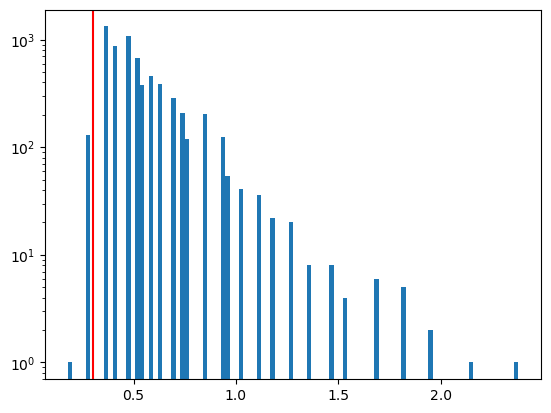

In [51]:
_ = plt.hist(min_age_all,bins=100)

plt.yscale('log')
plt.axvline(0.3,color='r')

In [15]:
def write_subvolume(subvolume,dict_results,dict_subvols,output_path):
    """
    parallelized function to write results of all halos belonging to same subvolume into the same output file.
    """
    
    print('Writing results for subvolume=%s'%subvolume,flush=True)
    
    # filter dict_results to only contain results for objects in current subvolume
    filtered_dict = {key:value for key,value in dict_results.items() if dict_subvols[key] == subvolume}
    
    # write this filtered dict as output
    np.savez(os.path.join(output_path+'output_subvolume_%s.npz'%subvolume), **filtered_dict)
    

def write(dict_results,tree_tables,parameters):
    """
    this will write solutions for halos of different subvolumes into different output files if needed.
    
    it uses parallelization to speed the writing process for multiple large files if needed.
    
    as of jan 6, 2023: the output file is a dict of dictionaries indexed by halo ID
    and is a compressed npz binary file -- we will switch to hdf5 or msgpack in the near future 
    """
    
    if parameters['tree_type'] in ['fire2_pandya22','fire2']:
        # just write a single output file since there are only 12 core halos
        np.savez(os.path.join(parameters['output_path']+'output.npz'), **dict_results)
        
    elif parameters['tree_type'] in ['tng']:
        
        # construct dict of halo_ID:subvolume pairs 
        print('creating dict_subvols',flush=True)
        dict_subvols = {str(key):value['subvolume'][0] for key,value in tree_tables.items()}
        subvolumes = np.unique(list(dict_subvols.values()))
        
        print(subvolumes,flush=True)
        
        # initialize multiprocessing pool of writer tasks as requested
        
        print('starting pool',flush=True)
        pool = multiprocessing.Pool(processes=parameters['num_writers'])

        print('creating partial writer functools',flush=True)
        # create a functools.partial object where dict_results and tree_tables are fixed and only subvolume varies between pool map calls
        pool_writer = partial(write_subvolume,dict_results=dict_results,dict_subvols=dict_subvols,output_path=parameters['output_path'])
        
        # map the write_subvolume function to each pair of (halo_name,tree_path) in parallel
        print('calling pool.map',flush=True)
        out = pool.map(pool_writer,subvolumes)
        
        print('closing and joining pool',flush=True)

        # close pool processes to free memory
        pool.close()
        pool.join()
        
    print('Finished writing output files to %s'%parameters['output_path'],flush=True)
    

In [ ]:
filtered_dict = {key:value for key,value in dict_results.items() if dict_subvols[key] == subvolume}

In [24]:
%%prun -s cumulative

# construct dict of halo_ID:subvolume pairs 
print('creating dict_subvols',flush=True)
dict_subvols = {str(key):value['subvolume'][0] for key,value in tree_tables.items()}
subvolumes = np.unique(list(dict_subvols.values()))
print(subvolumes,flush=True)

for subvolume in subvolumes:
    # filter dict_results to only contain results for objects in current subvolume
    filtered_dict = {key:value for key,value in dict_results.items() if dict_subvols[key] == subvolume}

    # write this filtered dict as output
    print('saving subvolume=%s'%subvolume)
    np.savez(os.path.join(parameters['output_path']+'output_subvolume_%s.npz'%subvolume), **filtered_dict)

    
print('finished!')

creating dict_subvols
['0_0_0' '0_0_1']
 

         82434 function calls (82432 primitive calls) in 103.040 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  103.040  103.040 {built-in method builtins.exec}
        1    0.000    0.000  103.039  103.039 <string>:1(<module>)
        3    0.000    0.000  103.034   34.345 {built-in method numpy.core._multiarray_umath.implement_array_function}
        2    0.000    0.000  103.034   51.517 <__array_function__ internals>:177(savez)
        2    0.000    0.000  103.033   51.516 npyio.py:531(savez)
        2    0.017    0.009  103.033   51.516 npyio.py:689(_savez)
      809    0.008    0.000   97.803    0.121 format.py:658(write_array)
      809   94.993    0.117   97.749    0.121 {built-in method _pickle.dump}
      809    0.003    0.000    5.153    0.006 {method '__exit__' of '_io._IOBase' objects}
      809    0.022    0.000    5.150    0.006 zipfile.py:1133(close)
     2431    5.094    0.002 

In [16]:
%%prun -s cumulative

write(dict_results,tree_tables,parameters)

creating dict_subvols
['0_0_0' '0_0_1']
starting pool
creating partial writer functools
calling pool.map
Writing results for subvolume=0_0_0
Writing results for subvolume=0_0_1


NameError: name 'os' is not defined

In [ ]:
len(dict_results)